# Household Electricity Consumption Prediction
**Case Study 27 · Semester V · Machine Learning**

This notebook uses the **real Kaggle/UCI Individual Household Electric Power Consumption dataset**: over two million minute readings from one home in Sceaux, France, recorded between December 2006 and November 2010. No households, attributes, or consumption targets are randomly generated.

The source has no household size, room count, appliance count, or separate AC hours. We therefore adapt the input features to genuine historical meter readings and calendar information. The output is **energy over the next 30 days (kWh)**, a standardised monthly forecasting horizon, rather than a calendar billing month.

A calendar-month aggregation gives fewer than 50 observations. Daily forecast origins provide more examples, but their 30-day targets overlap and are not independent. We use chronological evaluation with a 30-day gap and explicitly discuss this limitation.

## 1. Imports and reproducibility
All data cleaning, EDA, feature construction, five-model training, evaluation, and deployment exports happen here. The Streamlit app only loads the saved pipeline.

In [1]:
from pathlib import Path
import hashlib
import json
import urllib.request
import zipfile

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn
from IPython.display import Markdown, display
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import TimeSeriesSplit
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, PolynomialFeatures, StandardScaler
from sklearn.tree import DecisionTreeRegressor

ROOT = Path.cwd()
if not (ROOT / "data").exists():
    ROOT = ROOT.parent
assert (ROOT / "data").exists(), "Run this notebook from the project directory."
RAW = ROOT / "data/raw"
SOURCE = ROOT / "data/source"
PROCESSED = ROOT / "data/processed"
ARTIFACTS = ROOT / "artifacts"
for directory in [RAW, SOURCE, PROCESSED, ARTIFACTS]:
    directory.mkdir(parents=True, exist_ok=True)

SEED = 42
HORIZON = 30
SEASONS = ["Winter", "Spring", "Summer", "Autumn"]
plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({"figure.figsize": (11, 4), "axes.spines.top": False, "axes.spines.right": False})
print("pandas:", pd.__version__, "| scikit-learn:", sklearn.__version__)

pandas: 3.0.2 | scikit-learn: 1.8.0


## 2. Download and verify the real source
[Kaggle dataset](https://www.kaggle.com/datasets/uciml/electric-power-consumption-data-set) · [Original UCI documentation](https://archive.ics.uci.edu/dataset/235/individual+household+electric+power+consumption)

The exact downloaded ZIP is included in the repository so a fresh checkout can run without Kaggle credentials. If it is absent, this cell downloads it from Kaggle, with the original UCI archive as a fallback. SHA-256 checks prevent silently substituting another file.

Attribution: Hebrail, G. and Berard, A. (2006), Individual Household Electric Power Consumption, UCI Machine Learning Repository, DOI: 10.24432/C58K54. CC BY 4.0.

In [2]:
ARCHIVE = SOURCE / "household_power_consumption.zip"
RAW_FILE = RAW / "household_power_consumption.txt"
manifest_path = SOURCE / "source_metadata.json"
manifest = json.loads(manifest_path.read_text())
if not ARCHIVE.exists():
    urls = [
        ("kaggle", manifest["download_url"]),
        ("uci", "https://archive.ics.uci.edu/static/public/235/individual+household+electric+power+consumption.zip"),
    ]
    for provider, url in urls:
        try:
            request = urllib.request.Request(url, headers={"User-Agent": "Mozilla/5.0"})
            with urllib.request.urlopen(request, timeout=120) as response:
                payload = response.read()
            temporary = ARCHIVE.with_suffix(".tmp")
            temporary.write_bytes(payload)
            assert zipfile.is_zipfile(temporary), "Response is not a dataset ZIP."
            with zipfile.ZipFile(temporary) as archive:
                member = next(name for name in archive.namelist() if name.endswith("household_power_consumption.txt"))
                assert hashlib.sha256(archive.read(member)).hexdigest() == manifest["raw_sha256"], "Downloaded measurements differ from the pinned real dataset."
            temporary.replace(ARCHIVE)
            # ZIP packaging can differ at UCI; the original measurement hash stays pinned.
            manifest.update({
                "download_source": provider, "download_url": url,
                "archive_sha256": hashlib.sha256(payload).hexdigest(),
                "archive_bytes": len(payload),
            })
            manifest_path.write_text(json.dumps(manifest, indent=2) + "\n")
            print("Downloaded real source from", provider)
            break
        except Exception as error:
            print(provider, "download failed:", error)
    else:
        raise RuntimeError("Neither real source could be downloaded. No generated-data fallback.")

assert hashlib.sha256(ARCHIVE.read_bytes()).hexdigest() == manifest["archive_sha256"]
if not RAW_FILE.exists():
    with zipfile.ZipFile(ARCHIVE) as archive:
        member = next(name for name in archive.namelist() if name.endswith("household_power_consumption.txt"))
        RAW_FILE.write_bytes(archive.read(member))
assert hashlib.sha256(RAW_FILE.read_bytes()).hexdigest() == manifest["raw_sha256"]
print(f"Verified source: {RAW_FILE.stat().st_size:,} bytes")

Verified source: 132,960,755 bytes


## 3. Readings, units, and genuine missing values
Global_active_power is mean **kW during each minute**: sum over a day divided by 60 gives kWh.
Sub_metering_1, 2, and 3 are **Wh per minute**: divide their daily sums by 1,000.
Circuit 1 covers kitchen equipment, circuit 2 laundry equipment, and circuit 3 combines an electric water heater and air conditioner. Circuit 3 cannot identify separate AC use.

The file uses '?' for missing measurements. We do not inject artificial missing values.

In [3]:
measurement_columns = [
    "Global_active_power", "Global_reactive_power", "Voltage", "Global_intensity",
    "Sub_metering_1", "Sub_metering_2", "Sub_metering_3",
]
raw = pd.read_csv(RAW_FILE, sep=";", na_values=["?"], dtype={c: "float64" for c in measurement_columns})
timestamps = pd.to_datetime(raw["Date"] + " " + raw["Time"], format="%d/%m/%Y %H:%M:%S")
meter = raw[measurement_columns].copy()
meter.index = pd.DatetimeIndex(timestamps, name="timestamp")
meter = meter.sort_index()
assert len(meter) == 2_075_259 and meter.index.is_unique
assert meter.index.equals(pd.date_range(meter.index.min(), meter.index.max(), freq="min"))
missing_table = meter.isna().sum().to_frame("Missing minute readings")
display(missing_table)
display(raw.head())
print("Period:", meter.index.min(), "to", meter.index.max(), "| Measured households: 1")

,Missing minute readings
Global_active_power,25979
Global_reactive_power,25979
Voltage,25979
Global_intensity,25979
Sub_metering_1,25979
Sub_metering_2,25979
Sub_metering_3,25979


,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,16/12/2006,17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0
1,16/12/2006,17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0
2,16/12/2006,17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0
3,16/12/2006,17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0
4,16/12/2006,17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0


Period: 2006-12-16 17:24:00 to 2010-11-26 21:02:00 | Measured households: 1


## 4. Handle faulty-meter gaps and aggregate daily consumption
We forward-fill at most **five minutes** of a gap, using only preceding values. This is an explicit cleaning assumption, not a new dataset. Longer gaps remain missing. Partial first/last days and days with unresolved energy gaps are excluded from energy targets.

The notebook preserves observed and repaired counts. It also evaluates test targets containing zero repaired minutes separately. Historical feature gaps remaining after cleaning are median-imputed inside each training fold.

In [4]:
clean_meter = meter.ffill(limit=5)
repaired_power = meter["Global_active_power"].isna() & clean_meter["Global_active_power"].notna()
daily = pd.DataFrame({
    "recorded_minutes": meter["Global_active_power"].resample("D").size(),
    "observed_minutes": meter["Global_active_power"].resample("D").count(),
    "repaired_minutes": repaired_power.resample("D").sum().astype(int),
    "unresolved_minutes": clean_meter["Global_active_power"].isna().resample("D").sum().astype(int),
})
daily["usable_energy"] = (daily["recorded_minutes"] == 1440) & (daily["unresolved_minutes"] == 0)
daily["energy_kwh"] = (clean_meter["Global_active_power"].resample("D").sum(min_count=1440) / 60).where(daily["usable_energy"])
for source, destination in [
    ("Sub_metering_1", "kitchen_kwh"),
    ("Sub_metering_2", "laundry_kwh"),
    ("Sub_metering_3", "heating_ac_kwh"),
]:
    daily[destination] = clean_meter[source].resample("D").sum(min_count=1440) / 1000

def season_from_month(month):
    if month in [12, 1, 2]:
        return "Winter"
    if month in [3, 4, 5]:
        return "Spring"
    if month in [6, 7, 8]:
        return "Summer"
    return "Autumn"

daily.index.name = "date"
daily["month"] = daily.index.month
daily["year"] = daily.index.year
daily["season"] = [season_from_month(m) for m in daily["month"]]
daily.to_csv(PROCESSED / "daily_consumption.csv")
print(f"{len(daily):,} calendar days; {daily.usable_energy.sum():,} usable energy days")
print(f"{meter.Global_active_power.isna().sum():,} missing power minutes; {repaired_power.sum():,} repaired")
display(daily.describe().round(2))

1,442 calendar days; 1,410 usable energy days
25,979 missing power minutes; 156 repaired


,recorded_minutes,observed_minutes,repaired_minutes,unresolved_minutes,energy_kwh,kitchen_kwh,laundry_kwh,heating_ac_kwh,month,year
count,1442.00,1442.00,1442.00,1442.00,1410.00,1410.00,1410.00,1410.00,1442.00,1442.00
mean,1439.15,1421.14,0.11,17.91,26.20,1.62,1.87,9.31,6.45,2008.44
std,27.88,151.90,0.66,149.27,10.01,1.60,2.10,3.68,3.42,1.13
min,396.00,0.00,0.00,0.00,4.17,0.00,0.00,1.29,1.00,2006.00
25%,1440.00,1440.00,0.00,0.00,19.67,0.64,0.43,6.73,3.25,2007.00
50%,1440.00,1440.00,0.00,0.00,25.94,1.12,0.69,9.31,6.00,2008.00
75%,1440.00,1440.00,0.00,0.00,31.67,2.22,2.74,11.77,9.00,2009.00
max,1440.00,1440.00,10.00,1440.00,79.56,11.22,12.11,23.74,12.00,2010.00


## 5. Exploratory data analysis
Inspect demand over time, its distribution, seasonal variation, measured circuits, and meter coverage. These are observations from one French home; summer demand need not be the highest.

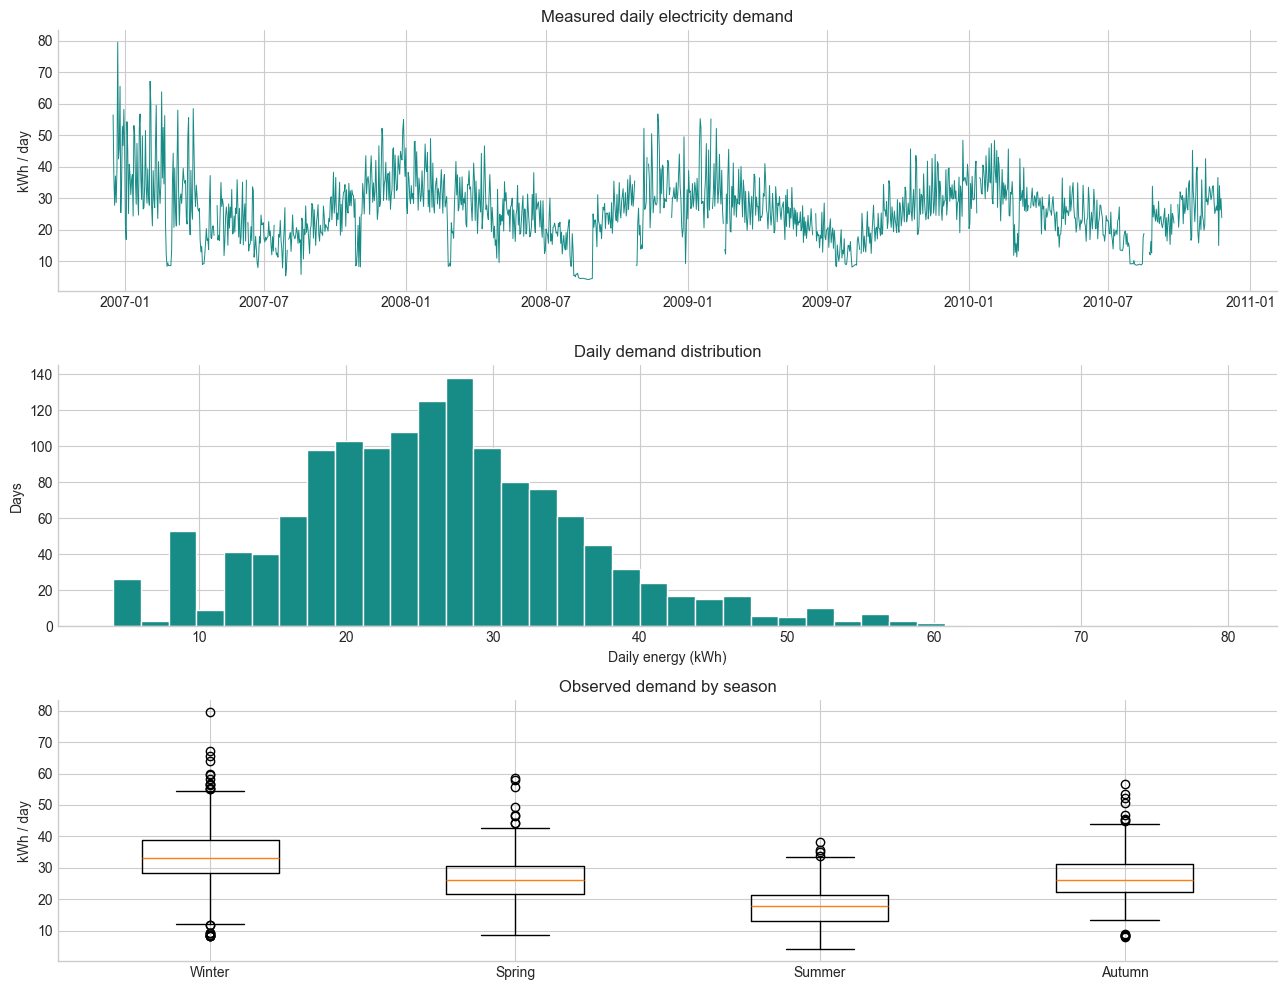

,count,mean,median,std
season,,,,
Winter,339,34.04,33.01,10.33
Spring,363,26.48,26.33,7.53
Summer,355,17.42,17.87,6.77
Autumn,353,27.21,26.29,7.50


In [5]:
fig, axes = plt.subplots(3, 1, figsize=(13, 10))
axes[0].plot(daily.index, daily.energy_kwh, color="#178b86", linewidth=.7)
axes[0].set(title="Measured daily electricity demand", ylabel="kWh / day")
axes[1].hist(daily.energy_kwh.dropna(), bins=40, color="#178b86", edgecolor="white")
axes[1].set(title="Daily demand distribution", xlabel="Daily energy (kWh)", ylabel="Days")
groups = [daily.loc[daily.season == s, "energy_kwh"].dropna() for s in SEASONS]
axes[2].boxplot(groups, tick_labels=SEASONS)
axes[2].set(title="Observed demand by season", ylabel="kWh / day")
plt.tight_layout()
plt.show()
display(daily.groupby("season").energy_kwh.agg(["count", "mean", "median", "std"]).reindex(SEASONS).round(2))

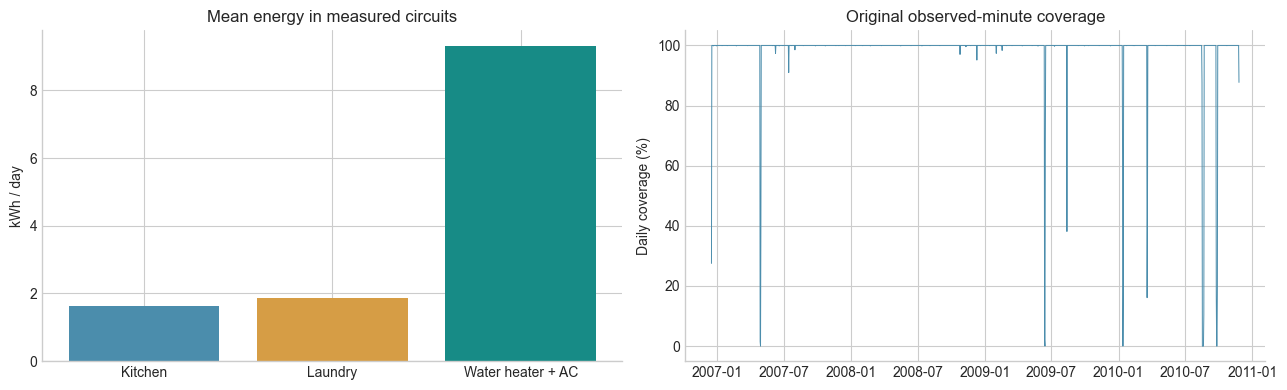

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
circuits = daily[["kitchen_kwh", "laundry_kwh", "heating_ac_kwh"]].mean()
axes[0].bar(["Kitchen", "Laundry", "Water heater + AC"], circuits, color=["#4b8dac", "#d69d45", "#178b86"])
axes[0].set(title="Mean energy in measured circuits", ylabel="kWh / day")
axes[1].plot(daily.index, daily.observed_minutes / 1440 * 100, linewidth=.7, color="#4b8dac")
axes[1].set(title="Original observed-minute coverage", ylabel="Daily coverage (%)")
plt.tight_layout()
plt.show()

## 6. Construct causal features and the 30-day target
For an origin on day t, the target is the energy sum for t through t+29. Every historical input ends at t−1. The previous 30-day total addresses the case study's previous-consumption question.

Month is encoded with sine/cosine so December and January are neighbours. Season is also one-hot encoded inside the pipeline; these related features can share importance. The output is derived from actual readings, with the short-gap repair flags retained.

In [7]:
records = pd.DataFrame(index=daily.index)
records["previous_30_day_kwh"] = daily.energy_kwh.rolling(30, min_periods=30).sum().shift(1)
records["previous_7_day_mean_kwh"] = daily.energy_kwh.rolling(7, min_periods=7).mean().shift(1)
records["previous_day_kwh"] = daily.energy_kwh.shift(1)
for circuit in ["kitchen", "laundry", "heating_ac"]:
    records[f"{circuit}_7_day_mean_kwh"] = daily[f"{circuit}_kwh"].rolling(7, min_periods=7).mean().shift(1)
records["month_sin"] = np.sin(2 * np.pi * records.index.month / 12)
records["month_cos"] = np.cos(2 * np.pi * records.index.month / 12)
records["season"] = daily.season
records["next_30_day_kwh"] = daily.energy_kwh.rolling(30, min_periods=30).sum().shift(-(HORIZON - 1))
records["target_repaired_minutes"] = daily.repaired_minutes.rolling(30, min_periods=30).sum().shift(-(HORIZON - 1))
records["forecast_end"] = records.index + pd.Timedelta(days=HORIZON - 1)
records = records.loc[records.index >= daily.index.min() + pd.Timedelta(days=31)]
records = records.dropna(subset=["next_30_day_kwh"]).reset_index(names="forecast_date")
records.to_csv(PROCESSED / "forecast_records.csv", index=False)

input_features = [
    "previous_30_day_kwh", "previous_7_day_mean_kwh", "previous_day_kwh",
    "kitchen_7_day_mean_kwh", "laundry_7_day_mean_kwh", "heating_ac_7_day_mean_kwh",
]
numeric_features = input_features + ["month_sin", "month_cos"]
feature_columns = numeric_features + ["season"]
X = records[feature_columns]
y = records.next_30_day_kwh
print(f"{len(records):,} labelled 30-day forecast examples, not independent households")
display(X.isna().sum().to_frame("Historical feature gaps"))
display(records.head())

957 labelled 30-day forecast examples, not independent households


,Historical feature gaps
previous_30_day_kwh,251
previous_7_day_mean_kwh,73
previous_day_kwh,11
kitchen_7_day_mean_kwh,73
laundry_7_day_mean_kwh,73
heating_ac_7_day_mean_kwh,73
month_sin,0
month_cos,0
season,0


,forecast_date,previous_30_day_kwh,previous_7_day_mean_kwh,previous_day_kwh,kitchen_7_day_mean_kwh,laundry_7_day_mean_kwh,heating_ac_7_day_mean_kwh,month_sin,month_cos,season,next_30_day_kwh,target_repaired_minutes,forecast_end
0,2007-01-16,1231.772200,38.302081,35.811300,2.074143,2.965857,11.569714,0.5,0.866025,Winter,1128.431000,1.0,2007-02-14
1,2007-01-17,1203.371267,37.867200,28.106733,2.127714,2.448286,11.111571,0.5,0.866025,Winter,1133.413367,1.0,2007-02-15
2,2007-01-18,1214.102300,39.516933,47.461467,2.517571,2.631286,11.833286,0.5,0.866025,Winter,1114.327367,1.0,2007-02-16
3,2007-01-19,1216.690100,38.484238,30.357700,2.320714,2.369286,11.987000,0.5,0.866025,Winter,1118.584867,1.0,2007-02-17
4,2007-01-20,1204.268300,38.529819,24.674000,2.621143,2.353714,11.829286,0.5,0.866025,Winter,1157.740233,1.0,2007-02-18


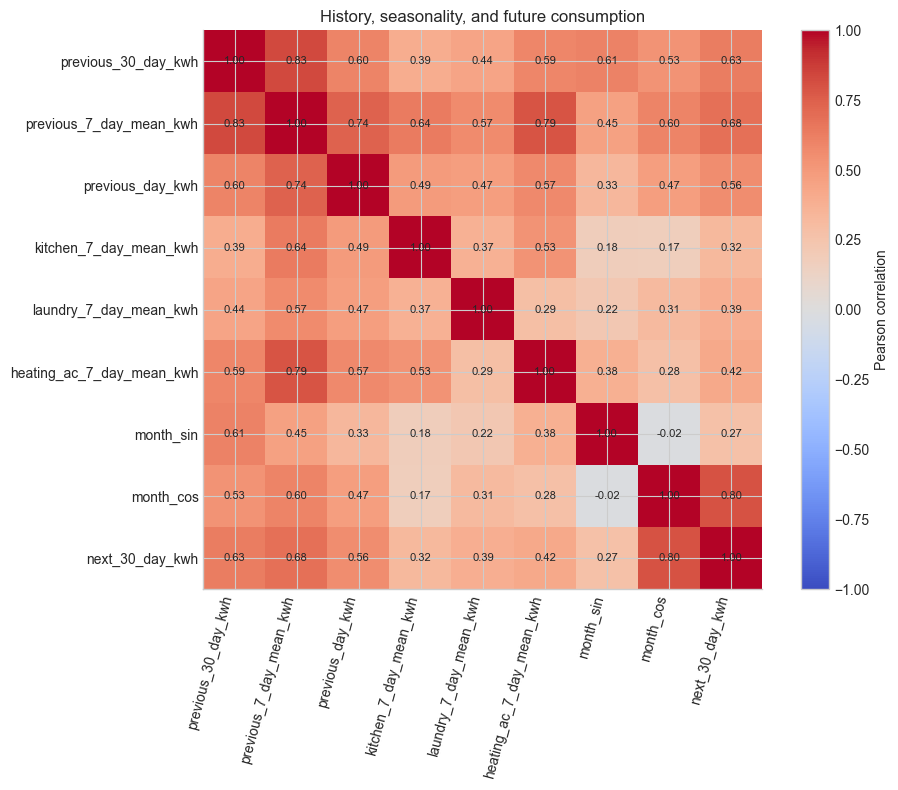

In [8]:
correlations = records[numeric_features + ["next_30_day_kwh"]].corr()
fig, ax = plt.subplots(figsize=(10, 8))
image = ax.imshow(correlations, cmap="coolwarm", vmin=-1, vmax=1)
ax.set_xticks(range(len(correlations)), correlations.columns, rotation=75, ha="right")
ax.set_yticks(range(len(correlations)), correlations.columns)
for row in range(len(correlations)):
    for column in range(len(correlations)):
        ax.text(column, row, f"{correlations.iloc[row, column]:.2f}", ha="center", va="center", fontsize=8)
fig.colorbar(image, ax=ax, label="Pearson correlation")
ax.set_title("History, seasonality, and future consumption")
plt.tight_layout()
plt.show()

## 7. Chronological holdout and five-fold cross-validation
Random splits would let adjacent, overlapping targets leak across folds. Reserve the latest approximately 20% of forecast origins for a final holdout, discarding training origins whose target reaches the holdout.

Within the earlier training partition, use five expanding time-series folds with a **30-row gap**. Since there is at most one origin per date, this is at least 30 calendar days. Assertions verify that every training target ends before validation begins.

This measures future periods of the same home. It cannot measure performance on unseen homes.

In [9]:
test_start = records.forecast_date.iloc[int(len(records) * .8)]
train_mask = records.forecast_end < test_start
test_mask = records.forecast_date >= test_start
X_train, y_train = X.loc[train_mask], y.loc[train_mask]
X_test, y_test = X.loc[test_mask], y.loc[test_mask]
train_records, test_records = records.loc[train_mask], records.loc[test_mask]
assert train_records.forecast_end.max() < test_records.forecast_date.min()
cv = TimeSeriesSplit(n_splits=5, gap=HORIZON)
fold_dates = []
for fold, (training, validation) in enumerate(cv.split(X_train), 1):
    last_target = train_records.iloc[training].forecast_end.max()
    first_validation = train_records.iloc[validation].forecast_date.min()
    assert last_target < first_validation
    fold_dates.append({
        "Fold": fold, "Training rows": len(training), "Validation rows": len(validation),
        "Last training target end": last_target.date(), "Validation starts": first_validation.date(),
    })
display(pd.DataFrame(fold_dates))
print("Final holdout starts:", test_start.date())
print("Training:", len(X_train), "| Holdout:", len(X_test), "| Discarded boundary:", len(records) - len(X_train) - len(X_test))

,Fold,Training rows,Validation rows,Last training target end,Validation starts
0,1,96,122,2007-09-06,2007-09-08
1,2,218,122,2008-01-06,2008-01-08
2,3,340,122,2008-05-07,2008-05-09
3,4,462,122,2008-09-06,2008-09-08
4,5,584,122,2009-05-08,2009-05-10


Final holdout starts: 2009-12-09
Training: 736 | Holdout: 192 | Discarded boundary: 29


## 8. Required models and preprocessing
Compare Linear Regression, degree-two Polynomial Regression, Decision Tree, Random Forest, and Gradient Boosting. Median imputation, scaling, and categorical encoding are fitted separately in each training fold.

Tree complexity is restricted to reduce overfitting on this small, correlated set of forecast origins. Parameters are specified before viewing holdout results. We select the lowest mean validation RMSE, not the lowest holdout error.

In [10]:
def make_preprocessing(polynomial=False):
    steps = [("imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler())]
    if polynomial:
        steps.append(("polynomial", PolynomialFeatures(degree=2, include_bias=False)))
    return ColumnTransformer([
        ("numeric", Pipeline(steps), numeric_features),
        ("season", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
        ]), ["season"]),
    ])

estimators = {
    "Linear Regression": LinearRegression(),
    "Polynomial Regression": LinearRegression(),
    "Decision Tree Regressor": DecisionTreeRegressor(max_depth=5, min_samples_leaf=10, random_state=SEED),
    "Random Forest Regressor": RandomForestRegressor(n_estimators=250, max_depth=8, min_samples_leaf=6, n_jobs=-1, random_state=SEED),
    "Gradient Boosting Regressor": GradientBoostingRegressor(n_estimators=150, learning_rate=.05, max_depth=2, min_samples_leaf=10, random_state=SEED),
}
models = {
    name: Pipeline([("preprocessing", make_preprocessing(name == "Polynomial Regression")), ("regressor", estimator)])
    for name, estimator in estimators.items()
}
def regression_metrics(actual, predicted):
    mse = float(mean_squared_error(actual, predicted))
    return {
        "R2": float(r2_score(actual, predicted)),
        "MSE": mse,
        "RMSE": float(np.sqrt(mse)),
        "MAE": float(mean_absolute_error(actual, predicted)),
    }

In [11]:
fold_results = []
for name, pipeline in models.items():
    for fold, (training, validation) in enumerate(cv.split(X_train), 1):
        fitted = clone(pipeline).fit(X_train.iloc[training], y_train.iloc[training])
        predicted = fitted.predict(X_train.iloc[validation])
        fold_results.append({"Model": name, "Fold": fold, **regression_metrics(y_train.iloc[validation], predicted)})
    print("Completed chronological CV:", name)
fold_metrics = pd.DataFrame(fold_results)
cv_summary = fold_metrics.groupby("Model").agg(
    CV_RMSE=("RMSE", "mean"), CV_RMSE_std=("RMSE", "std"),
    CV_MAE=("MAE", "mean"), CV_MSE=("MSE", "mean"), CV_R2=("R2", "mean"),
)
selected_model = cv_summary.CV_RMSE.idxmin()
print("Selected using training-only CV:", selected_model)
display(cv_summary.sort_values("CV_RMSE").round(3))
fold_metrics.to_csv(ARTIFACTS / "cv_fold_metrics.csv", index=False)

Completed chronological CV: Linear Regression


Completed chronological CV: Polynomial Regression
Completed chronological CV: Decision Tree Regressor


Completed chronological CV: Random Forest Regressor


Completed chronological CV: Gradient Boosting Regressor
Selected using training-only CV: Random Forest Regressor


,CV_RMSE,CV_RMSE_std,CV_MAE,CV_MSE,CV_R2
Model,,,,,
Random Forest Regressor,119.426,45.225,93.627,15898.722,0.028
Gradient Boosting Regressor,121.303,43.356,96.321,16218.336,0.000
Decision Tree Regressor,143.501,57.081,110.274,23199.162,-0.354
Linear Regression,165.538,134.124,140.545,41794.159,-1.103
Polynomial Regression,565.717,855.100,428.115,904992.587,-40.240


In [12]:
fitted_models = {}
holdout_predictions = {}
all_model_metrics = {}
for name, pipeline in models.items():
    fitted_models[name] = clone(pipeline).fit(X_train, y_train)
    holdout_predictions[name] = fitted_models[name].predict(X_test)
    all_model_metrics[name] = {
        **regression_metrics(y_test, holdout_predictions[name]),
        **{key: float(value) for key, value in cv_summary.loc[name].items()},
    }
comparison = pd.DataFrame.from_dict(all_model_metrics, orient="index").sort_values("CV_RMSE")
display(comparison.round(3))
best_model = fitted_models[selected_model]
best_predictions = holdout_predictions[selected_model]
test_metrics = regression_metrics(y_test, best_predictions)

,R2,MSE,RMSE,MAE,CV_RMSE,CV_RMSE_std,CV_MAE,CV_MSE,CV_R2
Random Forest Regressor,0.870,3153.905,56.160,43.112,119.426,45.225,93.627,15898.722,0.028
Gradient Boosting Regressor,0.914,2080.800,45.616,34.966,121.303,43.356,96.321,16218.336,0.000
Decision Tree Regressor,0.853,3561.474,59.678,41.418,143.501,57.081,110.274,23199.162,-0.354
Linear Regression,0.735,6406.354,80.040,66.843,165.538,134.124,140.545,41794.159,-1.103
Polynomial Regression,0.618,9232.297,96.085,76.988,565.717,855.100,428.115,904992.587,-40.240


## 9. Persistence baseline and capacity-planning interpretation
A useful model should be compared with a simple forecast: repeat the previous 30-day consumption. Both forecasts are scored on the **same holdout rows** where that history is complete.

RMSE measures root mean squared error in kWh: larger errors receive greater weight. It is the typical squared-error magnitude, not MAE and not a confidence interval. A negative R² means the model is worse than predicting the holdout mean under this metric.

,R2,MSE,RMSE,MAE
Persistence (previous 30 days),0.099,17739.890,133.191,104.112
Random Forest Regressor,0.872,2514.149,50.141,40.553


Comparable rows: 99 | Selected ML beats persistence: True


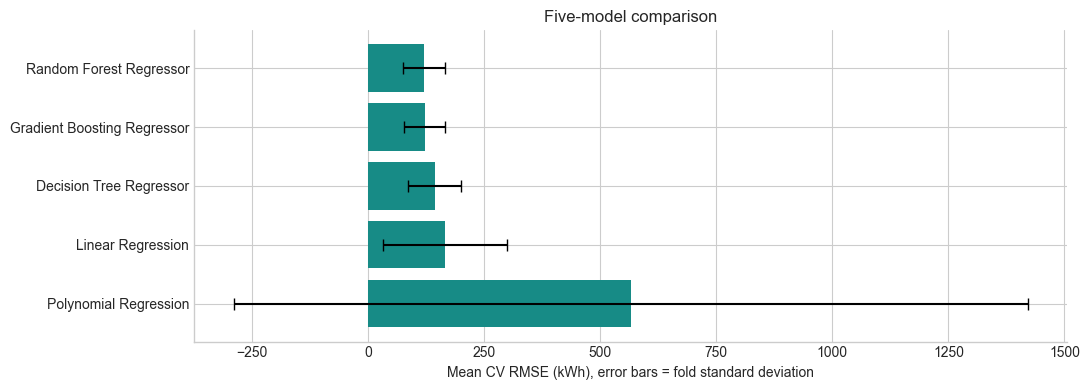

In [13]:
baseline_mask = X_test.previous_30_day_kwh.notna().to_numpy()
baseline_metrics = regression_metrics(y_test.iloc[baseline_mask], X_test.previous_30_day_kwh.iloc[baseline_mask])
model_on_baseline_rows = regression_metrics(y_test.iloc[baseline_mask], best_predictions[baseline_mask])
beats_baseline = model_on_baseline_rows["RMSE"] < baseline_metrics["RMSE"]
display(pd.DataFrame({
    "Persistence (previous 30 days)": baseline_metrics,
    selected_model: model_on_baseline_rows,
}).T.round(3))
print("Comparable rows:", int(baseline_mask.sum()), "| Selected ML beats persistence:", beats_baseline)
fig, ax = plt.subplots()
ordered = comparison.sort_values("CV_RMSE")
ax.barh(ordered.index, ordered.CV_RMSE, xerr=ordered.CV_RMSE_std, color="#178b86", capsize=4)
ax.invert_yaxis()
ax.set(xlabel="Mean CV RMSE (kWh), error bars = fold standard deviation", title="Five-model comparison")
plt.tight_layout()
plt.show()

## 10. Residual analysis of the selected model
Residual = actual − predicted. Inspect bias, changing spread, large errors, and time dependence. Overlapping 30-day targets naturally induce serial correlation, so a visually smooth error series does not provide independent evidence of accuracy.

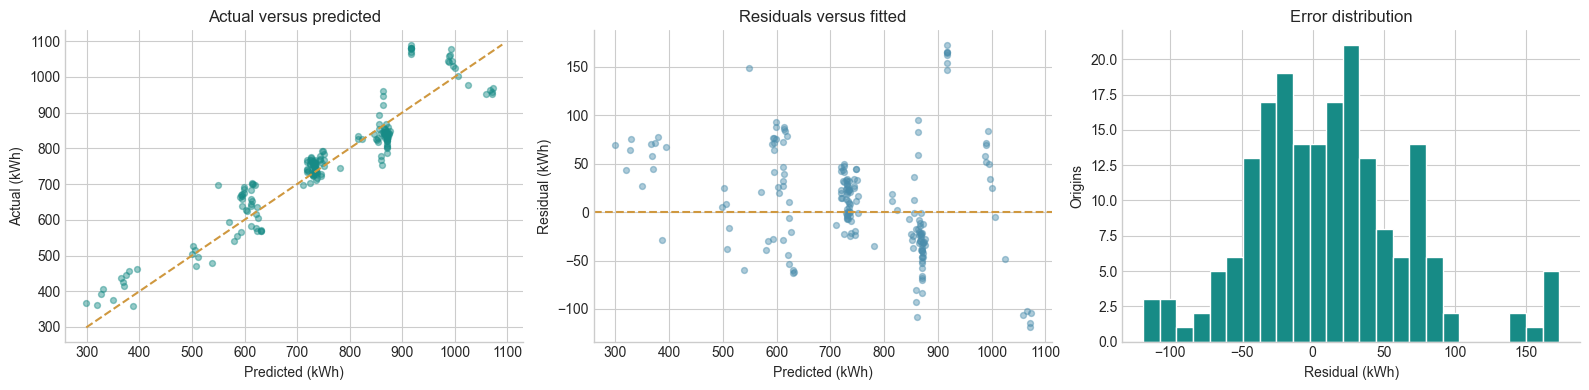

In [14]:
test_predictions = test_records[[
    "forecast_date", "forecast_end", "season", "previous_30_day_kwh", "target_repaired_minutes",
]].copy()
test_predictions["actual"] = y_test.to_numpy()
test_predictions["predicted"] = best_predictions
test_predictions["residual"] = y_test.to_numpy() - best_predictions
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
axes[0].scatter(best_predictions, y_test, alpha=.45, s=18, color="#178b86")
bounds = [min(y_test.min(), best_predictions.min()), max(y_test.max(), best_predictions.max())]
axes[0].plot(bounds, bounds, "--", color="#cf983f")
axes[0].set(xlabel="Predicted (kWh)", ylabel="Actual (kWh)", title="Actual versus predicted")
axes[1].scatter(best_predictions, test_predictions.residual, alpha=.45, s=18, color="#4b8dac")
axes[1].axhline(0, linestyle="--", color="#cf983f")
axes[1].set(xlabel="Predicted (kWh)", ylabel="Residual (kWh)", title="Residuals versus fitted")
axes[2].hist(test_predictions.residual, bins=25, color="#178b86", edgecolor="white")
axes[2].set(xlabel="Residual (kWh)", ylabel="Origins", title="Error distribution")
plt.tight_layout()
plt.show()

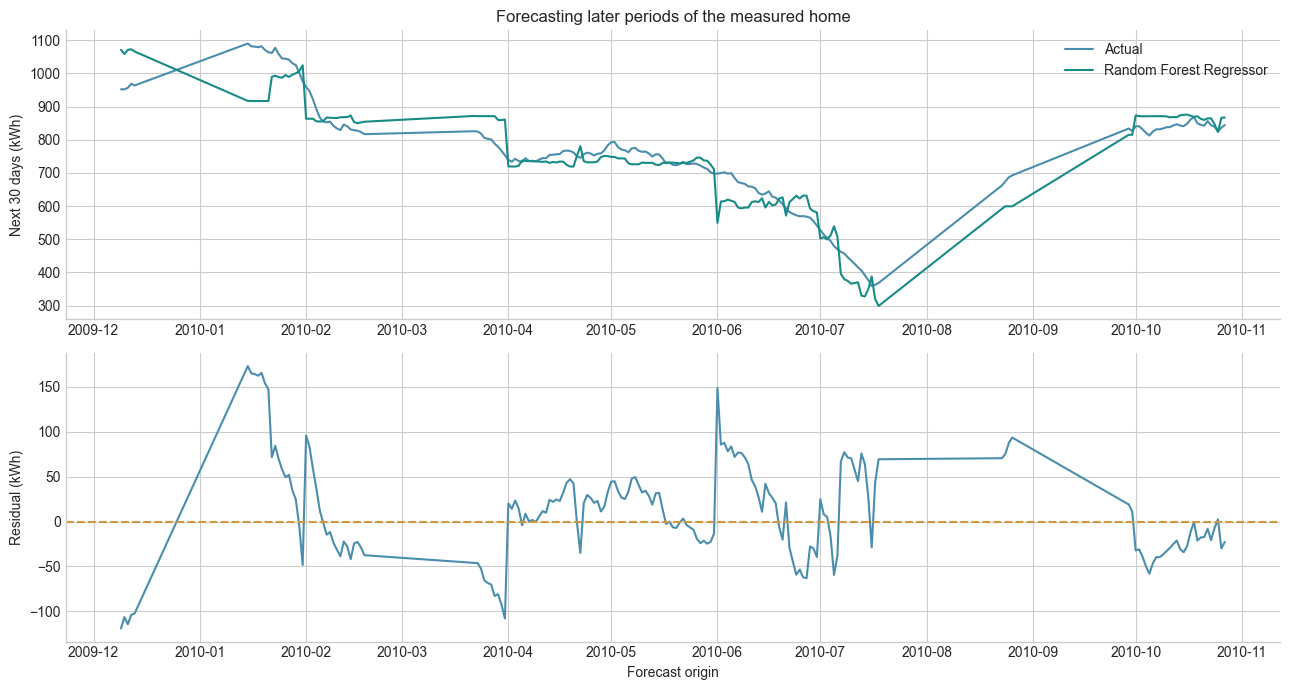

,count,mean,std
predicted,,,
"(298.76000000000005, 612.916]",39,38.15,45.77
"(612.916, 731.03]",38,15.34,39.66
"(731.03, 820.024]",38,10.75,19.73
"(820.024, 870.87]",38,-18.84,39.27
"(870.87, 1072.718]",39,5.35,90.55


Residual standard-deviation ratio across prediction bands: 4.59
Lag-one residual correlation: 0.811


In [15]:
fig, axes = plt.subplots(2, 1, figsize=(13, 7))
axes[0].plot(test_predictions.forecast_date, test_predictions.actual, label="Actual", color="#4b8dac")
axes[0].plot(test_predictions.forecast_date, test_predictions.predicted, label=selected_model, color="#178b86")
axes[0].set(ylabel="Next 30 days (kWh)", title="Forecasting later periods of the measured home")
axes[0].legend()
axes[1].plot(test_predictions.forecast_date, test_predictions.residual, color="#4b8dac")
axes[1].axhline(0, linestyle="--", color="#cf983f")
axes[1].set(ylabel="Residual (kWh)", xlabel="Forecast origin")
plt.tight_layout()
plt.show()
bands = pd.qcut(test_predictions.predicted, 5, duplicates="drop")
spread = test_predictions.groupby(bands, observed=True).residual.agg(["count", "mean", "std"])
spread_ratio = float(spread["std"].max() / spread["std"].min())
residual_correlation = float(test_predictions.residual.autocorr())
display(spread.round(2))
print(f"Residual standard-deviation ratio across prediction bands: {spread_ratio:.2f}")
print(f"Lag-one residual correlation: {residual_correlation:.3f}")

## 11. Seasonal accuracy and influential factors
Compare observed demand across all years with holdout seasonal averages. The holdout does not cover every season; absence of a season must not be treated as zero error.

Permutation importance measures predictive reliance by shuffling an original input and measuring the increase in test RMSE. Correlated history and calendar inputs can divide or mask importance. These values do not establish causal effects.

,Origins,Actual mean,Predicted mean,RMSE,MAE
Season,,,,,
Winter,40,954.24,930.87,87.12,69.69
Spring,71,754.95,752.52,36.29,28.25
Summer,52,567.19,537.12,59.29,52.32
Autumn,29,839.24,863.36,29.73,26.35


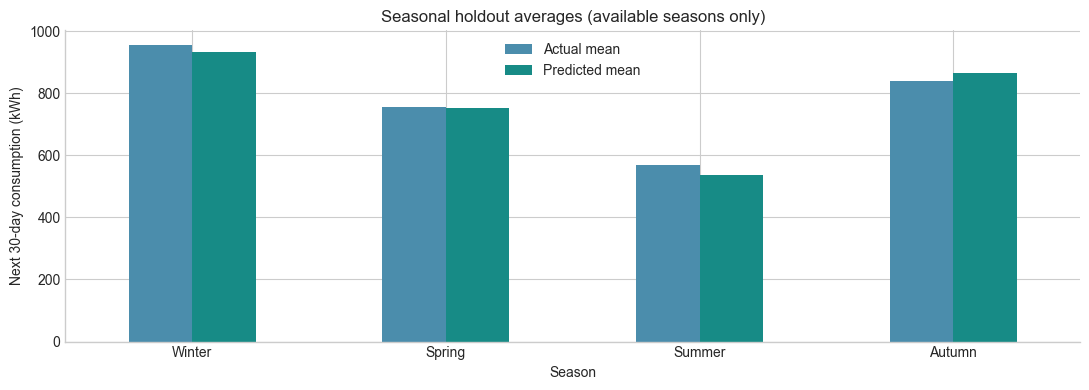

,feature,rmse_increase,std
8,season,100.238,7.949
7,month_cos,69.799,4.145
0,previous_30_day_kwh,6.626,1.822
6,month_sin,0.677,0.520
3,kitchen_7_day_mean_kwh,0.552,0.348
2,previous_day_kwh,0.124,0.057
4,laundry_7_day_mean_kwh,-1.153,1.292
5,heating_ac_7_day_mean_kwh,-1.575,0.373
1,previous_7_day_mean_kwh,-2.149,0.569


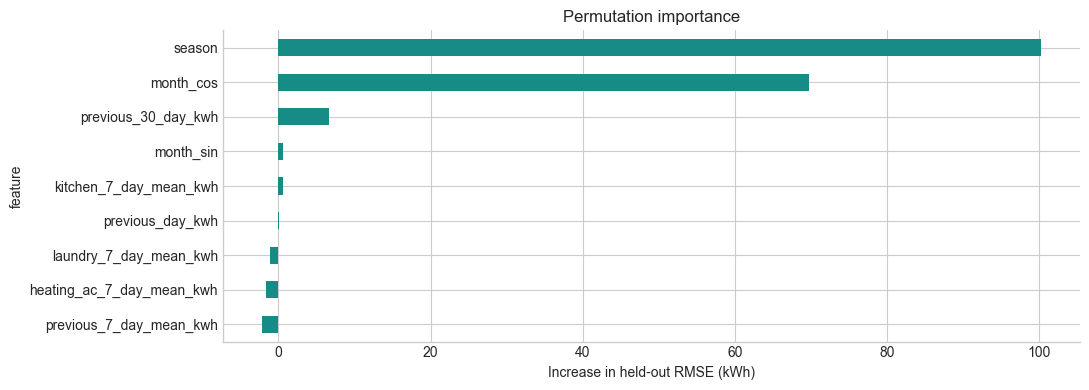

In [16]:
season_rows = []
for season, group in test_predictions.groupby("season"):
    season_rows.append({
        "Season": season, "Origins": len(group),
        "Actual mean": group.actual.mean(), "Predicted mean": group.predicted.mean(),
        "RMSE": np.sqrt(mean_squared_error(group.actual, group.predicted)),
        "MAE": mean_absolute_error(group.actual, group.predicted),
    })
season_performance = pd.DataFrame(season_rows).set_index("Season").reindex(SEASONS)
display(season_performance.round(2))
season_performance[["Actual mean", "Predicted mean"]].dropna().plot.bar(color=["#4b8dac", "#178b86"])
plt.ylabel("Next 30-day consumption (kWh)")
plt.title("Seasonal holdout averages (available seasons only)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

permuted = permutation_importance(best_model, X_test, y_test, scoring="neg_root_mean_squared_error", n_repeats=5, random_state=SEED)
importance = pd.DataFrame({
    "feature": feature_columns, "rmse_increase": permuted.importances_mean, "std": permuted.importances_std,
}).sort_values("rmse_increase", ascending=False)
display(importance.round(3))
importance.sort_values("rmse_increase").plot.barh(x="feature", y="rmse_increase", legend=False, color="#178b86")
plt.xlabel("Increase in held-out RMSE (kWh)")
plt.title("Permutation importance")
plt.tight_layout()
plt.show()

In [17]:
fully_observed_mask = test_predictions.target_repaired_minutes.eq(0).to_numpy()
fully_observed_metrics = None
if fully_observed_mask.sum() >= 2:
    fully_observed_metrics = regression_metrics(y_test.iloc[fully_observed_mask], best_predictions[fully_observed_mask])
    print("Targets built from entirely observed minutes:", int(fully_observed_mask.sum()))
    display(pd.DataFrame([fully_observed_metrics]).round(3))
else:
    print("Too few fully observed holdout targets to estimate sensitivity separately.")

Targets built from entirely observed minutes: 16


,R2,MSE,RMSE,MAE
0,0.914,2499.845,49.998,41.925


## 12. Refit and export for Streamlit
After model selection and holdout evaluation, refit the selected pipeline on all labelled examples for deployment. Stored diagnostics remain predictions from the earlier training-only fit; do not recompute them with the deployment model.

The app uses six measured-history inputs and derives the calendar encoding from the forecast date. Example profiles are actual rows, not generated households. The displayed error range is prediction ± holdout RMSE; it has no guaranteed probability coverage.

In [18]:
deployment_model = clone(models[selected_model]).fit(X, y)
joblib.dump(deployment_model, ARTIFACTS / "best_model.joblib")
test_predictions.to_csv(ARTIFACTS / "test_predictions.csv", index=False)
importance.to_csv(ARTIFACTS / "feature_importance.csv", index=False)

bounds = {
    column: {"min": float(X[column].min()), "max": float(X[column].max()), "median": float(X[column].median())}
    for column in input_features
}
complete_examples = records.dropna(subset=input_features)
presets = []
for name, quantile in [("Typical measured history", .5), ("Lower-demand history", .2), ("Higher-demand history", .8)]:
    row = complete_examples.loc[(complete_examples.previous_30_day_kwh - complete_examples.previous_30_day_kwh.quantile(quantile)).abs().idxmin()]
    presets.append({
        "name": name, "forecast_date": row.forecast_date.strftime("%Y-%m-%d"),
        "inputs": {column: float(row[column]) for column in input_features},
    })
config = {
    "dataset_type": "real_meter_readings", "households": 1, "horizon_days": HORIZON,
    "feature_columns": feature_columns, "input_features": input_features,
    "numeric_features": numeric_features, "categorical_features": ["season"],
    "target_column": "next_30_day_kwh", "target_unit": "kWh", "season_options": SEASONS,
    "bounds": bounds, "presets": presets,
}
metrics = {
    "selected_model": selected_model, "selection_metric": "CV_RMSE",
    "cross_validation": "5-fold expanding TimeSeriesSplit, 30-row gap",
    "horizon_days": HORIZON, "rows": len(records), "train_rows": len(X_train), "test_rows": len(X_test),
    "test_date_range": [test_records.forecast_date.min().strftime("%Y-%m-%d"), test_records.forecast_date.max().strftime("%Y-%m-%d")],
    "last_training_target_end": train_records.forecast_end.max().strftime("%Y-%m-%d"),
    "test_metrics": test_metrics, "all_model_metrics": all_model_metrics,
    "baseline_metrics": baseline_metrics, "model_on_baseline_rows": model_on_baseline_rows,
    "baseline_comparable_rows": int(baseline_mask.sum()), "beats_persistence_baseline": bool(beats_baseline),
    "fully_observed_test_rows": int(fully_observed_mask.sum()), "fully_observed_test_metrics": fully_observed_metrics,
    "residual_std_ratio": spread_ratio, "residual_lag1_correlation": residual_correlation,
    "sklearn_version": sklearn.__version__,
}
metadata = {
    **manifest, "raw_rows": len(meter), "households": 1, "horizon_days": HORIZON,
    "date_range": [str(meter.index.min()), str(meter.index.max())],
    "missing_power_minutes": int(meter.Global_active_power.isna().sum()),
    "repaired_power_minutes": int(repaired_power.sum()),
    "max_forward_fill_minutes": 5, "daily_rows": len(daily),
    "usable_energy_days": int(daily.usable_energy.sum()), "forecast_examples": len(records),
}
for path, payload in [
    (ARTIFACTS / "metrics.json", metrics),
    (ARTIFACTS / "feature_config.json", config),
    (PROCESSED / "dataset_metadata.json", metadata),
]:
    path.write_text(json.dumps(payload, indent=2, allow_nan=False) + "\n")
print("Saved real-data artifacts. Deployment model refitted on", len(records), "labelled origins.")

Saved real-data artifacts. Deployment model refitted on

 957 labelled origins.


## 13. Answer the case-study questions using the actual results
The next cell calculates its conclusions from the executed results rather than assuming an algorithm wins.

In [19]:
top_feature = importance.iloc[0].feature
holdout_winner = comparison.RMSE.idxmin()
season_importance = float(importance.set_index("feature").loc["season", "rmse_increase"])
baseline_statement = (
    "The selected ML model beats persistence on the comparable holdout rows."
    if beats_baseline else
    "Persistence has lower holdout RMSE on the comparable rows; ML has not demonstrated an improvement over that practical baseline."
)
display(Markdown(f'''
1. **Can consumption be predicted?** The selected model is {selected_model}, with holdout RMSE **{test_metrics["RMSE"]:.2f} kWh**, MAE **{test_metrics["MAE"]:.2f} kWh**, and R² **{test_metrics["R2"]:.3f}** for the next 30 days of this home. {baseline_statement}
2. **Which factor has the greatest effect?** The largest permutation RMSE increase is for **{top_feature}**. This identifies predictive reliance, not a causal household effect.
3. **Is seasonality captured?** Calendar seasonality contributes to predictions: shuffling the season raises test RMSE by **{season_importance:.2f} kWh**. The daily plots and seasonal holdout averages show how closely that variation is captured. Seasonal holdout errors above show where performance is adequate or poor; the holdout covers only its listed seasons.
4. **Do residuals have constant variance?** Prediction-band residual standard deviations differ by **{spread_ratio:.2f}×**. A constant-variance assumption is not established; inspect the residual scatter. Lag-one error correlation is **{residual_correlation:.3f}**, partly reflecting overlapping targets.
5. **Which algorithm has the lowest RMSE?** **{selected_model}** has the lowest mean training CV RMSE (**{comparison.loc[selected_model, "CV_RMSE"]:.2f} kWh**) and is selected before inspecting the holdout. **{holdout_winner}** has the lowest final holdout RMSE (**{comparison.loc[holdout_winner, "RMSE"]:.2f} kWh**). We report that separately rather than changing selection after seeing the holdout.
6. **How does it perform on new households?** Unknown: there is only one measured household. The test evaluates later periods of that same home.
7. **Can it be deployed for demand forecasting?** The Streamlit demo predicts next-30-day energy and shows ±RMSE as a rough planning range. Utility use requires validation on recent, multi-household readings, weather, and independent forecast origins.
'''))


1. **Can consumption be predicted?** The selected model is Random Forest Regressor, with holdout RMSE **56.16 kWh**, MAE **43.11 kWh**, and R² **0.870** for the next 30 days of this home. The selected ML model beats persistence on the comparable holdout rows.
2. **Which factor has the greatest effect?** The largest permutation RMSE increase is for **season**. This identifies predictive reliance, not a causal household effect.
3. **Is seasonality captured?** Calendar seasonality contributes to predictions: shuffling the season raises test RMSE by **100.24 kWh**. The daily plots and seasonal holdout averages show how closely that variation is captured. Seasonal holdout errors above show where performance is adequate or poor; the holdout covers only its listed seasons.
4. **Do residuals have constant variance?** Prediction-band residual standard deviations differ by **4.59×**. A constant-variance assumption is not established; inspect the residual scatter. Lag-one error correlation is **0.811**, partly reflecting overlapping targets.
5. **Which algorithm has the lowest RMSE?** **Random Forest Regressor** has the lowest mean training CV RMSE (**119.43 kWh**) and is selected before inspecting the holdout. **Gradient Boosting Regressor** has the lowest final holdout RMSE (**45.62 kWh**). We report that separately rather than changing selection after seeing the holdout.
6. **How does it perform on new households?** Unknown: there is only one measured household. The test evaluates later periods of that same home.
7. **Can it be deployed for demand forecasting?** The Streamlit demo predicts next-30-day energy and shows ±RMSE as a rough planning range. Utility use requires validation on recent, multi-household readings, weather, and independent forecast origins.


## 14. Limitations and real-world applicability
- The dataset represents one French household in 2006–2010; climate, household equipment, tariffs, and behaviour may differ from today's homes.
- Required demographic attributes are absent. We cannot conclude the effect of household size or room count, or infer separate AC hours from the combined circuit.
- Five-minute forward filling approximates short outages. Longer outages and incomplete target windows are excluded, potentially selecting more reliable periods.
- Adjacent 30-day windows overlap. The chronological gaps prevent shared target minutes between training and validation, but validation errors still correlate, reducing the effective sample size.
- Forecasts omit temperature, humidity, holidays, occupancy changes, and solar generation. Calendar season is an incomplete substitute for weather.
- The final holdout spans only part of a year. CV averages and fold variability should be considered alongside the holdout.
- Permutation importance is affected by correlated history and calendar inputs. Controlled input changes in the app are model sensitivity demonstrations, not causal predictions.
- A 30-day horizon is not an exact calendar month. Summed energy does not predict peak instantaneous load, which is also necessary for grid capacity planning.
- ±RMSE is not a calibrated prediction interval. Operational intervals need time-aware calibration and prospective coverage checks.
- Refit deployment estimates on historical example rows are demonstrations; only saved training-only holdout predictions support the reported test scores.

**Reproduce:** Run all cells from a fresh kernel, then launch Streamlit with streamlit run app.py. All source measurements are real; preprocessing and feature aggregation are documented above.